In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
sns.set_style(style='whitegrid')

In [3]:
df=pd.read_csv("../data/pmu_data.csv")
df.head(10)

,timestamp,Va_mag,Va_ang,Vb_mag,Vb_ang,Vc_mag,Vc_ang,Ia_mag,Ia_ang,Ib_mag,Ib_ang,Ic_mag,Ic_ang,frequency,rocof
0,2026-02-10 14:07:15,132243.95,176.93,131467.20,56.92,132248.10,-63.08,247.44,-3.71,246.75,-123.82,246.94,116.08,59.9988,-0.0350
1,2026-02-10 14:07:15,132243.22,176.92,131468.32,56.92,132247.88,-63.09,247.46,-3.69,246.94,-123.89,246.76,116.10,59.9994,0.0631
2,2026-02-10 14:07:15,132241.92,176.92,131469.08,56.92,132247.48,-63.09,247.50,-3.74,246.95,-123.89,246.76,116.08,60.0001,0.0450
3,2026-02-10 14:07:15,132242.01,176.92,131468.25,56.91,132246.94,-63.09,247.53,-3.78,246.98,-123.90,246.85,116.11,59.9996,-0.0460
4,2026-02-10 14:07:15,132243.03,176.91,131467.20,56.91,132246.70,-63.09,247.25,-3.73,247.01,-123.91,246.96,116.19,59.9989,-0.0572
5,2026-02-10 14:07:15,132243.44,176.91,131467.79,56.90,132247.21,-63.10,247.10,-3.69,247.01,-123.91,246.89,116.16,59.9990,0.0230
6,2026-02-10 14:07:15,132243.75,176.91,131468.13,56.90,132247.63,-63.10,247.38,-3.69,246.89,-123.87,247.09,116.05,59.9997,0.0547
7,2026-02-10 14:07:15,132243.88,176.90,131467.95,56.90,132247.38,-63.11,247.49,-3.71,246.66,-123.79,247.19,116.04,59.9995,-0.0226
8,2026-02-10 14:07:15,132243.19,176.90,131468.57,56.89,132247.19,-63.11,247.43,-3.70,246.78,-123.83,246.82,116.08,59.9990,-0.0408
9,2026-02-10 14:07:16,132242.61,176.89,131468.78,56.89,132247.39,-63.11,247.44,-3.70,247.01,-123.91,246.72,116.10,59.9995,0.0424


In [4]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

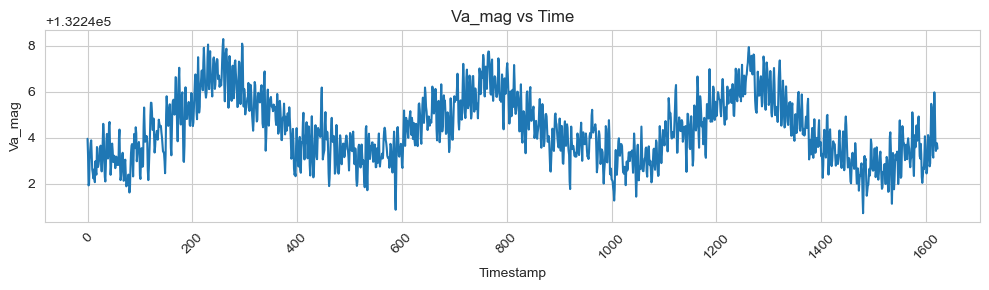

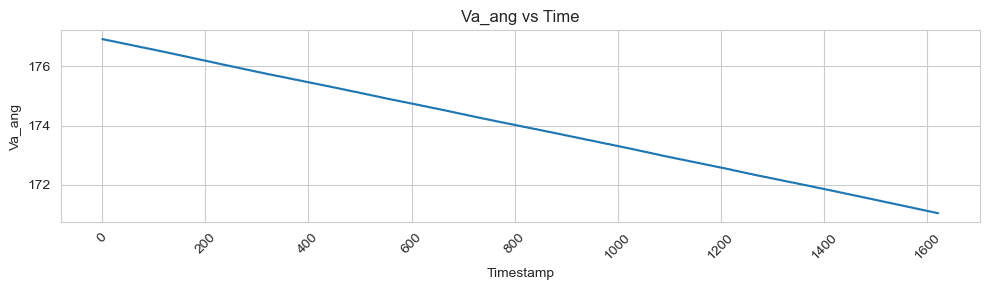

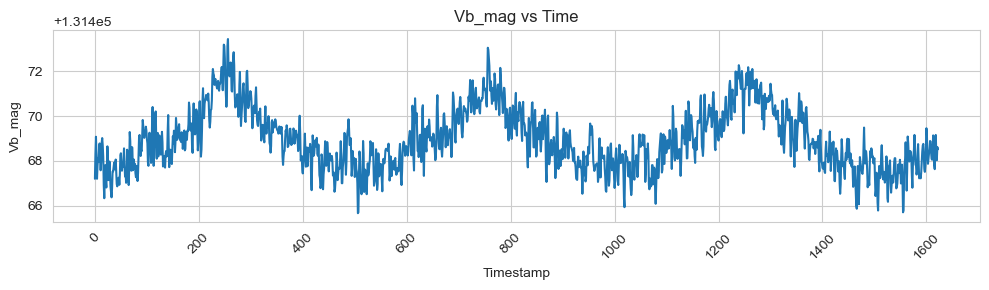

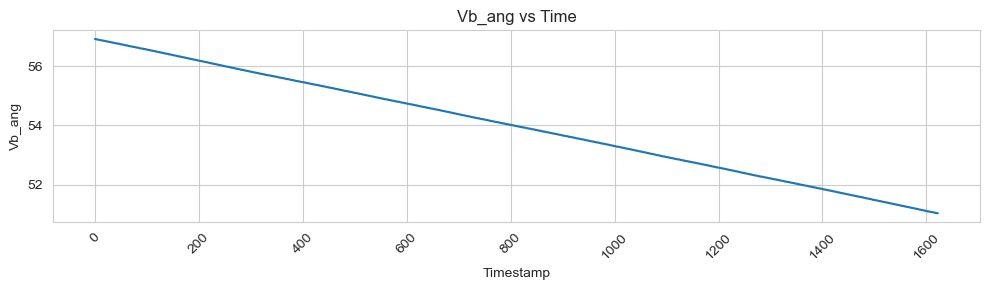

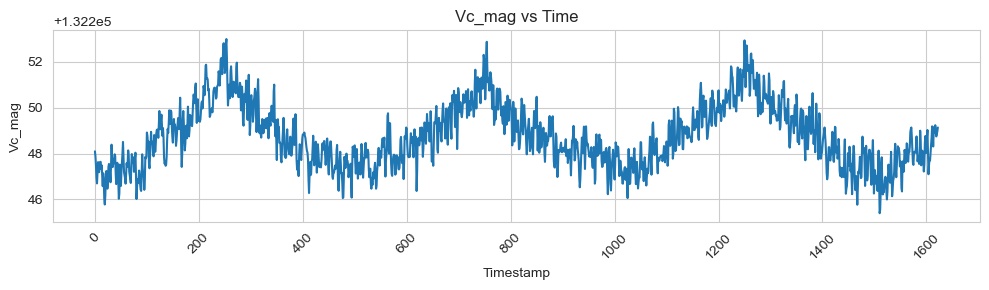

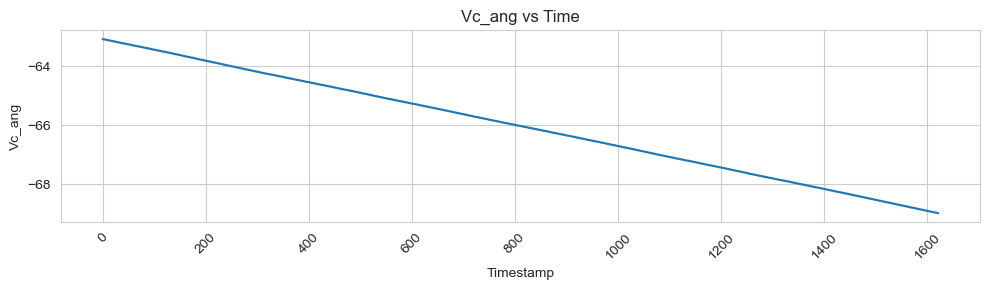

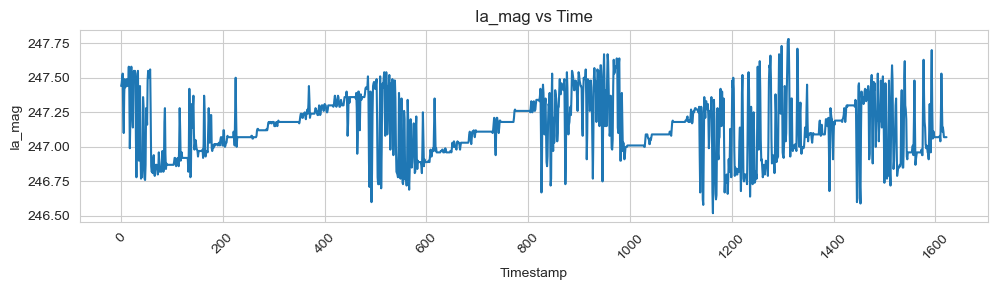

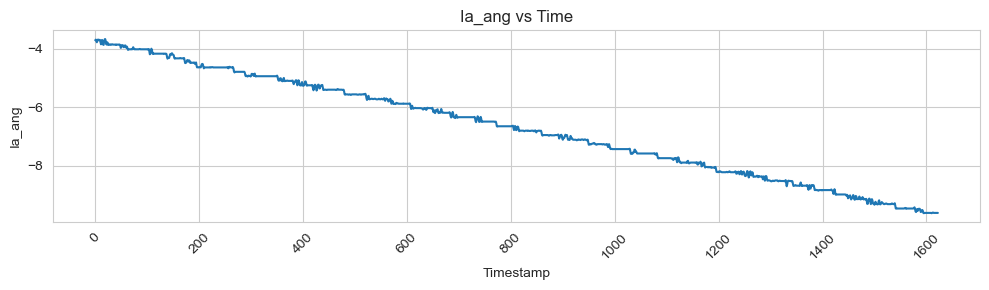

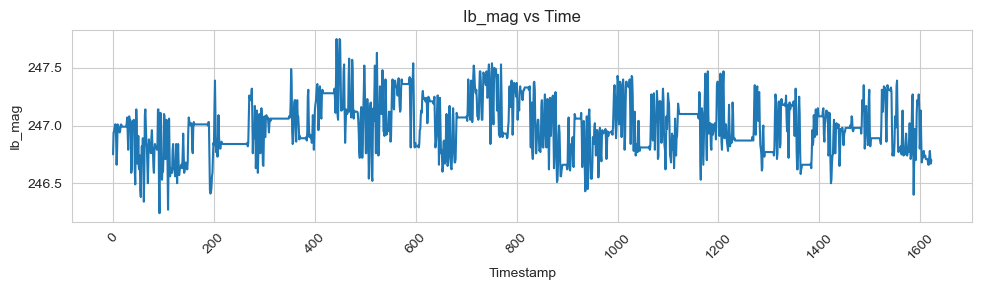

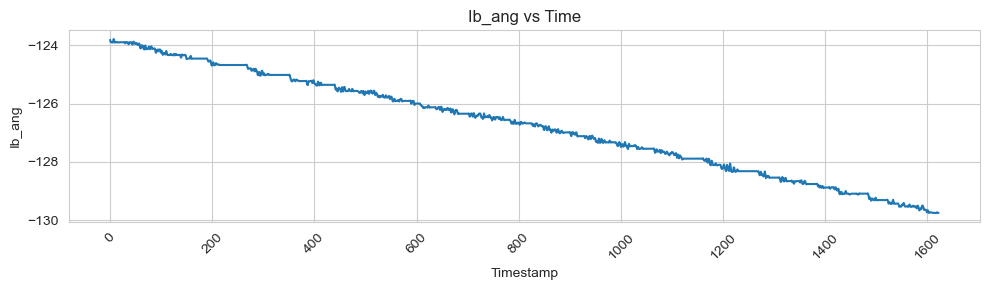

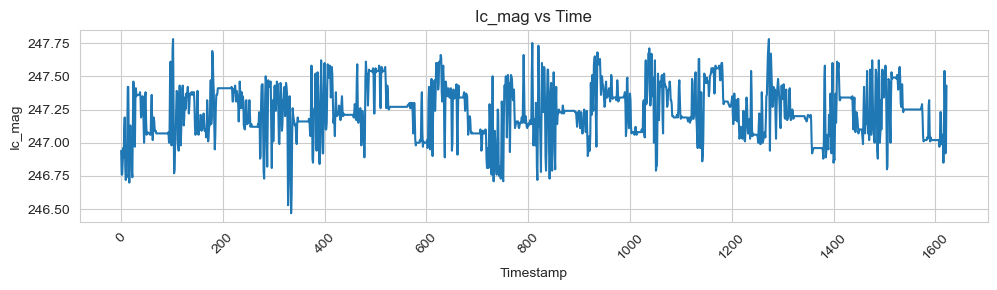

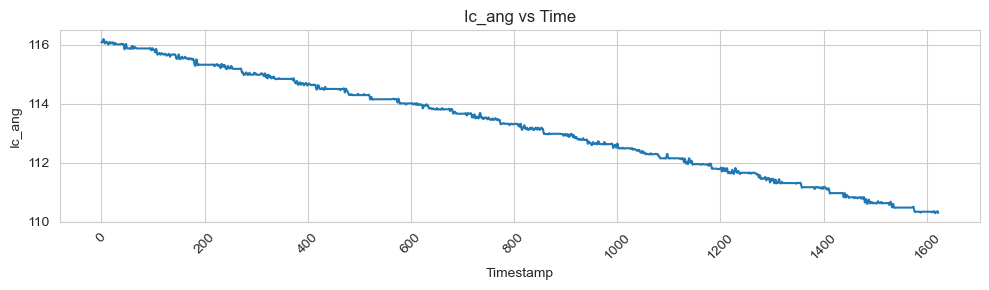

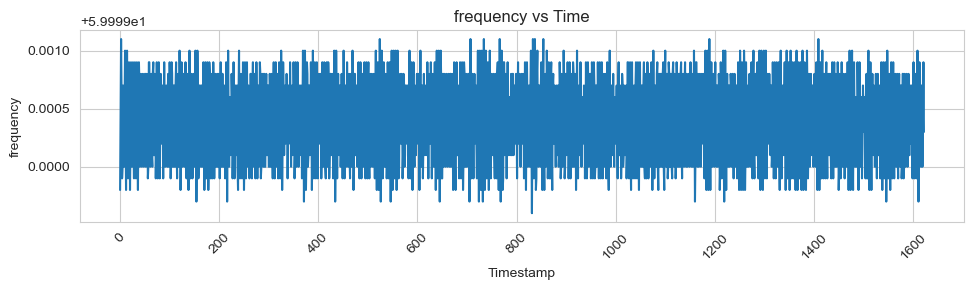

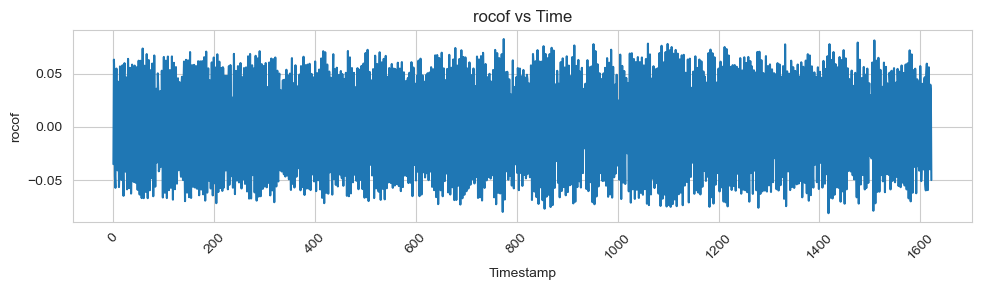

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

features = df.select_dtypes(include=['float64', 'int64']).columns

# Plot each feature separately
for col in features:
    plt.figure(figsize=(10, 3))
    plt.plot(df.index, df[col])
    plt.title(f"{col} vs Time")
    plt.xlabel("Timestamp")
    plt.ylabel(col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

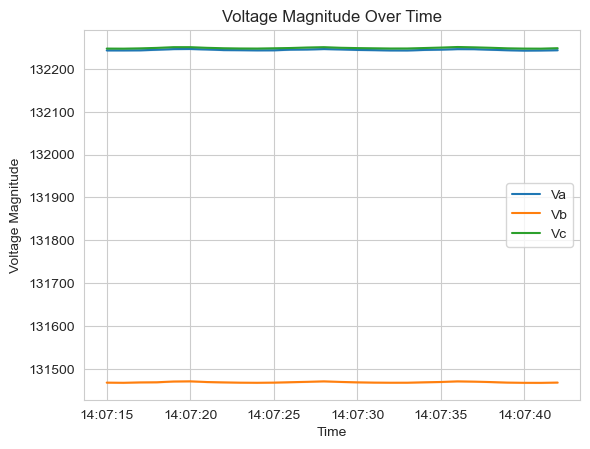

In [6]:
plt.figure()

sns.lineplot(x='timestamp', y='Va_mag', data=df, label='Va')
sns.lineplot(x='timestamp', y='Vb_mag', data=df, label='Vb')
sns.lineplot(x='timestamp', y='Vc_mag', data=df, label='Vc')

plt.title("Voltage Magnitude Over Time")
plt.xlabel("Time")
plt.ylabel("Voltage Magnitude")
plt.show()

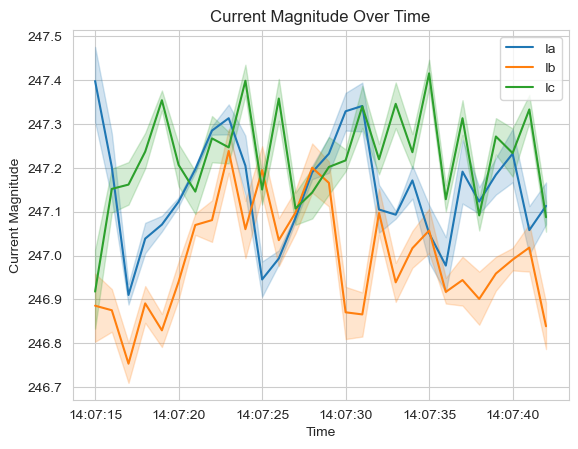

In [7]:
plt.figure()

sns.lineplot(x='timestamp', y='Ia_mag', data=df, label='Ia')
sns.lineplot(x='timestamp', y='Ib_mag', data=df, label='Ib')
sns.lineplot(x='timestamp', y='Ic_mag', data=df, label='Ic')

plt.title("Current Magnitude Over Time")
plt.xlabel("Time")
plt.ylabel("Current Magnitude")
plt.show()

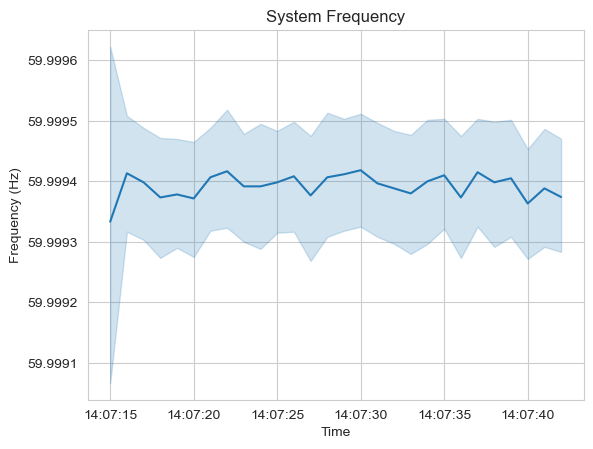

In [8]:
plt.figure()

ax=sns.lineplot(x='timestamp', y='frequency', data=df)
ax.yaxis.get_major_formatter().set_useOffset(False)
plt.title("System Frequency")
plt.xlabel("Time")
plt.ylabel("Frequency (Hz)")
plt.show()

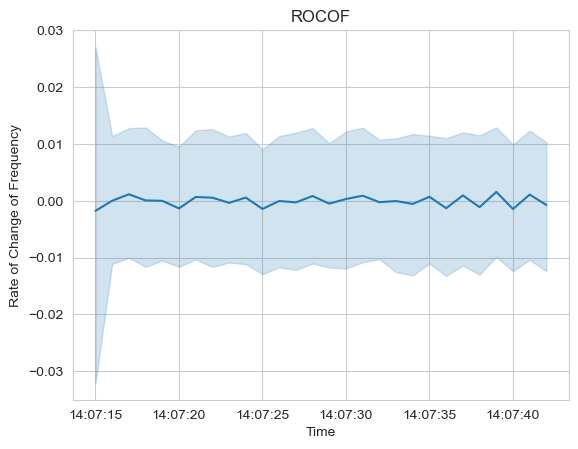

In [9]:
plt.figure()

ax=sns.lineplot(x='timestamp', y='rocof', data=df)
ax.yaxis.get_major_formatter().set_useOffset(False)

plt.title("ROCOF")
plt.xlabel("Time")
plt.ylabel("Rate of Change of Frequency")
plt.show()

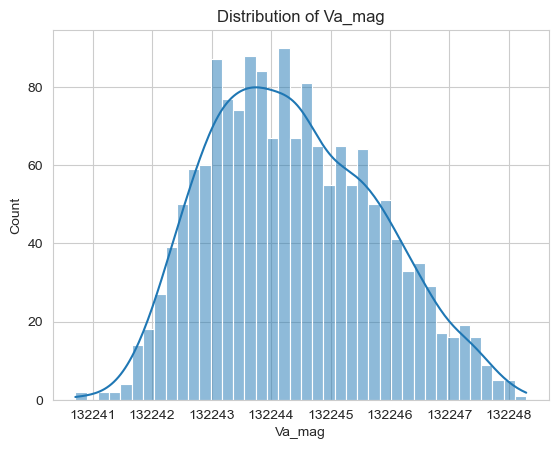

In [10]:
plt.figure()

ax=sns.histplot(df['Va_mag'], bins=40, kde=True)
ax.xaxis.get_major_formatter().set_useOffset(False)
plt.title("Distribution of Va_mag")
plt.show()

In [11]:
df.isnull().sum()

timestamp    0
Va_mag       0
Va_ang       0
Vb_mag       0
Vb_ang       0
Vc_mag       0
Vc_ang       0
Ia_mag       0
Ia_ang       0
Ib_mag       0
Ib_ang       0
Ic_mag       0
Ic_ang       0
frequency    0
rocof        0
dtype: int64

In [12]:
timestamp=df['timestamp']
feature=df.drop(columns=['timestamp'])

In [13]:
window_size=40
step=1

def create_windows(data, window_size, step_size):

    windows = []

    for i in range(0, len(data) - window_size, step_size):

        window = data[i:i+window_size]

        windows.append(window)

    return np.array(windows)


windows = create_windows(feature, 40, 1)

In [14]:
print("Window shape:", windows.shape)

Window shape: (1583, 40, 14)


In [15]:
df.shape

(1623, 15)

In [16]:
windows

array([[[ 1.3224395e+05,  1.7693000e+02,  1.3146720e+05, ...,
          1.1608000e+02,  5.9998800e+01, -3.5000000e-02],
        [ 1.3224322e+05,  1.7692000e+02,  1.3146832e+05, ...,
          1.1610000e+02,  5.9999400e+01,  6.3100000e-02],
        [ 1.3224192e+05,  1.7692000e+02,  1.3146908e+05, ...,
          1.1608000e+02,  6.0000100e+01,  4.5000000e-02],
        ...,
        [ 1.3224416e+05,  1.7679000e+02,  1.3146792e+05, ...,
          1.1601000e+02,  5.9999400e+01,  5.8400000e-02],
        [ 1.3224387e+05,  1.7679000e+02,  1.3146762e+05, ...,
          1.1602000e+02,  5.9999900e+01,  3.3300000e-02],
        [ 1.3224309e+05,  1.7679000e+02,  1.3146780e+05, ...,
          1.1603000e+02,  5.9999700e+01, -2.9300000e-02]],

       [[ 1.3224322e+05,  1.7692000e+02,  1.3146832e+05, ...,
          1.1610000e+02,  5.9999400e+01,  6.3100000e-02],
        [ 1.3224192e+05,  1.7692000e+02,  1.3146908e+05, ...,
          1.1608000e+02,  6.0000100e+01,  4.5000000e-02],
        [ 1.3224201e+05, 

# feature extraction 

In [17]:
import numpy as np

def extract_features(window):
    features = []

    
    Va_mag = window[:,0]
    Vb_mag = window[:,2]
    Vc_mag = window[:,4]

    
    Va_ang = window[:,1]
    Vb_ang = window[:,3]
    Vc_ang = window[:,5]

    
    Ia_mag = window[:,6]
    Ib_mag = window[:,8]
    Ic_mag = window[:,10]

    
    Ia_ang = window[:,7]
    Ib_ang = window[:,9]
    Ic_ang = window[:,11]

    # Frequency + ROCOF
    freq = window[:,12]
    rocof = window[:,13]

    
    # Convert angles to radians
    
    Va_rad = np.deg2rad(Va_ang)
    Vb_rad = np.deg2rad(Vb_ang)
    Vc_rad = np.deg2rad(Vc_ang)

    Ia_rad = np.deg2rad(Ia_ang)
    Ib_rad = np.deg2rad(Ib_ang)
    Ic_rad = np.deg2rad(Ic_ang)

   
    # Phase angle difference
   
    theta_a = Va_rad - Ia_rad
    theta_b = Vb_rad - Ib_rad
    theta_c = Vc_rad - Ic_rad

    
    # Power calculations
    
    Pa = Va_mag * Ia_mag * np.cos(theta_a)
    Pb = Vb_mag * Ib_mag * np.cos(theta_b)
    Pc = Vc_mag * Ic_mag * np.cos(theta_c)
    P_total = Pa + Pb + Pc

    Qa = Va_mag * Ia_mag * np.sin(theta_a)
    Qb = Vb_mag * Ib_mag * np.sin(theta_b)
    Qc = Vc_mag * Ic_mag * np.sin(theta_c)
    Q_total = Qa + Qb + Qc

    Sa = Va_mag * Ia_mag
    Sb = Vb_mag * Ib_mag
    Sc = Vc_mag * Ic_mag
    S_total = Sa + Sb + Sc

    
    # Helper: statistical features
    
    def add_stats(signal):
        signal = np.nan_to_num(signal)

        features.extend([
            np.mean(signal),
            np.std(signal),
            np.min(signal),
            np.max(signal),
            np.median(signal),
            np.percentile(signal, 75) - np.percentile(signal, 25),  # IQR
        ])

        # temporal features
        diff = np.diff(signal)
        if len(diff) > 0:
            features.extend([
                np.mean(diff),
                np.std(diff),
                np.max(np.abs(diff))
            ])
        else:
            features.extend([0, 0, 0])

    
    # Add features for all signals
    
    signals = [
        Va_mag, Vb_mag, Vc_mag,
        Ia_mag, Ib_mag, Ic_mag,
        Va_ang, Vb_ang, Vc_ang,
        Ia_ang, Ib_ang, Ic_ang,
        Pa, Pb, Pc, P_total,
        Qa, Qb, Qc, Q_total,
        Sa, Sb, Sc, S_total,
        freq, rocof
    ]

    for s in signals:
        add_stats(s)

    
    # Power system specific features
    

    # Voltage imbalance
    features.append(np.std([np.mean(Va_mag), np.mean(Vb_mag), np.mean(Vc_mag)]))

    # Current imbalance
    features.append(np.std([np.mean(Ia_mag), np.mean(Ib_mag), np.mean(Ic_mag)]))

    # Power factor (avoid divide by zero)
    pf = np.divide(P_total, S_total, out=np.zeros_like(P_total), where=S_total!=0)
    add_stats(pf)

    # Angle consistency
    features.append(np.std(Va_ang - Vb_ang))
    features.append(np.std(Vb_ang - Vc_ang))
    features.append(np.std(Va_ang - Vc_ang))

    # Frequency stability
    features.append(np.std(freq))

    # ROCOF spikes
    features.append(np.max(np.abs(rocof)))

    # -----------------------------
    return np.array(features, dtype=np.float32)

In [18]:
feature_dataset = []

for w in windows:

    feature_dataset.append(extract_features(w))

feature_dataset = np.array(feature_dataset)

print(feature_dataset.shape)

(1583, 250)


In [19]:
feature_dataset

array([[1.3224306e+05, 6.7562562e-01, 1.3224192e+05, ..., 2.6339134e-03,
        3.9273879e-04, 6.4700000e-02],
       [1.3224305e+05, 6.6151112e-01, 1.3224192e+05, ..., 2.6339134e-03,
        3.8625606e-04, 6.4700000e-02],
       [1.3224308e+05, 7.0071679e-01, 1.3224192e+05, ..., 2.6339134e-03,
        3.8923000e-04, 6.4700000e-02],
       ...,
       [1.3224367e+05, 9.3511218e-01, 1.3224203e+05, ..., 3.3071891e-03,
        3.5408331e-04, 6.9899999e-02],
       [1.3224367e+05, 9.3515342e-01, 1.3224203e+05, ..., 3.3071891e-03,
        3.4752698e-04, 6.9899999e-02],
       [1.3224366e+05, 9.3345112e-01, 1.3224203e+05, ..., 3.5707143e-03,
        3.4914180e-04, 6.8000004e-02]], dtype=float32)

In [20]:
# X_scaled -> train and test
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(feature_dataset, test_size=0.2, shuffle=False)

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [22]:
print(scaler.mean_)
print(scaler.scale_)

[ 1.32244545e+05  7.37010935e-01  1.32242948e+05  1.32246105e+05
  1.32244553e+05  9.94146922e-01  2.59650828e-03  6.26605132e-01
  1.49589258e+00  1.31469103e+05  6.99021701e-01  1.31467625e+05
  1.31470557e+05  1.31469105e+05  9.42573064e-01  2.48754404e-03
  5.92259452e-01  1.46376777e+00  1.32248887e+05  6.45198205e-01
  1.32247526e+05  1.32250238e+05  1.32248883e+05  8.61449447e-01
  2.62506580e-03  5.48736437e-01  1.32007108e+00  2.47133974e+02
  1.29179600e-01  2.46884550e+02  2.47381239e+02  2.47130821e+02
  1.59561611e-01 -1.64661575e-04  1.11276530e-01  2.88578199e-01
  2.47009222e+02  1.73521581e-01  2.46668143e+02  2.47340545e+02
  2.47012879e+02  2.26172986e-01 -2.22789362e-05  1.45319304e-01
  3.62938389e-01  2.47243080e+02  1.56724960e-01  2.46924881e+02
  2.47549693e+02  2.47239168e+02  1.89308847e-01  2.03750977e-04
  1.34260143e-01  3.63815164e-01  1.74558851e+02  4.20323523e-02
  1.74488041e+02  1.74629668e+02  1.74558847e+02  7.08254333e-02
 -3.63146591e-03  4.80703

In [23]:
X_train.shape

(1266, 250)

# model training


In [24]:
# isolation forest
from sklearn.ensemble import IsolationForest
model = IsolationForest(
        n_estimators=200,
        contamination=0.02,   # may have to adjust 
        random_state=42,
        n_jobs=-1
    )

    #model.fit(X_train)

In [25]:
#save for realtime use on the real sample
# import joblib

# joblib.dump(model, "isolation_model.pkl")
# joblib.dump(scaler, "scaler.pkl")

In [26]:
#GRU 
# 1 need labeled data (0 normal , 1 attack) 
# 2 convert labeled windows ()
# train based on this output [0,1]
